In [3]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [33]:
train=pd.read_csv("../data/processed/train.csv")
test=pd.read_csv("../data/processed/val.csv")

xTrainScaledSmote=np.load("../data/processed/xtrain_scaled.npy")
yTrainSeveritySmote=np.load("../data/processed/ytrain_severity.npy")

features = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
target = "cases"

xTrainScaled=train[features]

xTestScaled=test[features]
yTrain=train[target]

yTest=test[target]

In [34]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    meanSquareError=mean_squared_error(yTest, predictions)
    r2=r2_score(yTest, predictions)
    rootMeanSquareError=root_mean_squared_error(yTest, predictions)
    meanAbsoluteError=mean_absolute_error(yTest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [36]:
#Linear Regression as baseline model

linearRegression=LinearRegression()

linearRegression.fit(xTrainScaled,yTrain)

linearEvaluations=regressorEvaluation(linearRegression,xTestScaled,yTest)

timeCv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xTrainScaled,yTrain,cv=timeCv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")
jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: -1.6498931471534615
Mean Squared Error: 3.505118352876561
Root Mean Squared Error: 1.8721961309853625
Mean Absolute Error: 1.4615382144999298
Cross Validation Average R2 Score: 0.6566
Cross Validation R2 Scores Std: 0.0664
Mean: 0.6566 ± 0.0664


['../models/linear_baseline.pkl']

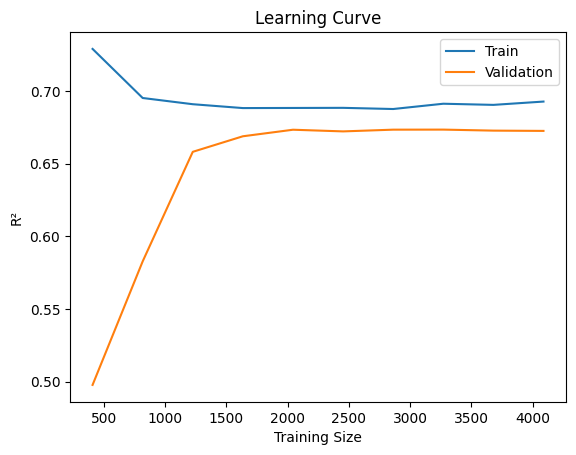

In [37]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    linearRegression, xTrainScaled, yTrain, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, test_scores.mean(axis=1),   label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [38]:
#randomforest regressor
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV

featuresRf = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
targetRf = "cases"

xTrainScaledRf=train[featuresRf]

xTestScaledRf=test[featuresRf]
yTrainRf=train[targetRf]

yTestRf=test[targetRf]

gridParameters={
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 8]
}

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
    )


tCsv=TimeSeriesSplit(n_splits=5)

gridSearch=GridSearchCV(
    estimator=model,
    param_grid=gridParameters,
    cv=tCsv,
    scoring='r2',
    n_jobs=-1
)

gridSearch.fit(xTrainScaledRf, yTrainRf)

model=gridSearch.best_estimator_
evaluation=regressorEvaluation(model, xTestScaledRf, yTestRf)
importance = model.feature_importances_

scores = cross_val_score(model, xTrainScaledRf, yTrainRf, cv=tCsv, scoring='r2')

print(f"CV R² scores: {scores.mean():.4f}")
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")

# 1. Check lag values at test boundary
print(test[['district', 'epi_week', 't1_cases', 't2_cases']].head(20))

# 2. Check prediction vs actual
preds = model.predict(xTestScaledRf)
print(f"Actual cases   — mean: {yTestRf.mean():.2f}, max: {yTestRf.max():.2f}")
print(f"Predicted cases — mean: {preds.mean():.2f}, max: {preds.max():.2f}")

# 3. Check isOutbreak in test
print(f"isOutbreak in test: {test['isOutbreak'].sum()}")
print(f"isOutbreak in train: {train['isOutbreak'].sum()}")

The Model Performance metrics are:
R2 Score: 0.40428069642324604
Mean Squared Error: 0.7879814574307434
Root Mean Squared Error: 0.8876831965463486
Mean Absolute Error: 0.5280937588183422
CV R² scores: 0.7419
Mean: 0.7419 ± 0.2289
   district  epi_week  t1_cases  t2_cases
0    attock         1       4.0       5.0
1    attock         2       2.0       4.0
2    attock         3       2.0       2.0
3    attock         4       2.0       2.0
4    attock         5       1.0       2.0
5    attock         6       2.0       1.0
6    attock         7       2.0       2.0
7    attock         8       2.0       2.0
8    attock         9       1.0       2.0
9    attock        10       1.0       1.0
10   attock        11       1.0       1.0
11   attock        12       1.0       1.0
12   attock        13       1.0       1.0
13   attock        14       1.0       1.0
14   attock        15       1.0       1.0
15   attock        16       1.0       1.0
16   attock        18       0.0       1.0
17   attock  

In [39]:
from xgboost import XGBRegressor as xgBoostRegressor


featuresXg = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
targetXg = "cases"

xTrainScaledXg=train[featuresXg]

xTestScaledXg=test[featuresXg]
yTrainXg=train[targetXg]

yTestXg=test[targetXg]

xgModel = xgBoostRegressor(
    learning_rate=0.01,    # slower learning
    n_estimators=1000,     # more trees to compensate
    max_depth=3,           # keep shallow
    subsample=0.8,         # add some randomness
    colsample_bytree=0.8,  # add some randomness
    min_child_weight=5,    # prevents overfitting on small groups
    random_state=42,
    n_jobs=-1
)

xgModel.fit(xTrainScaledXg, yTrainXg)
xgEvaluation=regressorEvaluation(xgModel, xTestScaledXg, yTestXg)
xgScores = cross_val_score(xgModel, xTrainScaledXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"XGBoost CV R² scores: {xgScores.mean():.4f}")
print(f"Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

The Model Performance metrics are:
R2 Score: 0.41258710622787476
Mean Squared Error: 0.7769942879676819
Root Mean Squared Error: 0.8814727663993835
Mean Absolute Error: 0.5977174639701843
XGBoost CV R² scores: 0.7550
Mean: 0.7550 ± 0.2032
